# Phase 3: Model Training, Evaluation, and Serialization

This notebook trains and evaluates the churn prediction models on the daily feature table built in Phase 2:
1. **Baseline**: Logistic Regression
2. **Championship**: XGBoost Classifier

Evaluation metrics include AUC-ROC, Precision@top-10%, Confusion Matrix, Calibration curve, Feature Importance, and a Demographic Fairness Slice Analysis. Finally, the model is serialized to `models/churn_model_pipeline.joblib`.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report, average_precision_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from xgboost import XGBClassifier

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
DATA_DIR = "./data"
MODELS_DIR = "./models"
os.makedirs(MODELS_DIR, exist_ok=True)
print("Setup completed successfully.")

Setup completed successfully.


## 1. Load Feature Data

In [2]:
features_path = os.path.join(DATA_DIR, "fct_member_features_daily.parquet")
df = pd.read_parquet(features_path)
print(f"Loaded feature table. Total records: {len(df):,}")
df['date_day'] = pd.to_datetime(df['date_day'])
print(f"Timeline: {df['date_day'].min().date()} to {df['date_day'].max().date()}")

Loaded feature table. Total records: 2,037,425
Timeline: 2024-01-01 to 2026-05-31


## 2. Chronological Train-Val-Test Split

In [3]:
# Chronological Splitting
train_df = df[df['date_day'] < '2025-09-01']
val_df = df[(df['date_day'] >= '2025-09-01') & (df['date_day'] < '2026-01-01')]
test_df = df[df['date_day'] >= '2026-01-01']

print(f"Train size: {len(train_df):,} rows ({train_df['date_day'].min().date()} to {train_df['date_day'].max().date()})")
print(f"Validation size: {len(val_df):,} rows ({val_df['date_day'].min().date()} to {val_df['date_day'].max().date()})")
print(f"Test size: {len(test_df):,} rows ({test_df['date_day'].min().date()} to {test_df['date_day'].max().date()})")

# Check class balances
print(f"\nTrain target rate: {train_df['is_churned_14d'].mean():.2%}")
print(f"Val target rate: {val_df['is_churned_14d'].mean():.2%}")
print(f"Test target rate: {test_df['is_churned_14d'].mean():.2%}")

Train size: 1,067,659 rows (2024-01-01 to 2025-08-31)
Validation size: 396,487 rows (2025-09-01 to 2025-12-31)
Test size: 573,279 rows (2026-01-01 to 2026-05-31)

Train target rate: 0.54%
Val target rate: 0.87%
Test target rate: 1.50%


## 3. Preprocessing Setup

In [4]:
# Columns definition
categorical_cols = ['gender', 'home_studio_id', 'membership_tier']
numeric_cols = [
    'age', 'monthly_price', 'tenure_days', 'sessions_booked_7d', 'sessions_booked_30d', 
    'sessions_attended_7d', 'sessions_attended_30d', 'attendance_rate_7d', 'attendance_rate_30d', 
    'avg_sauna_temp_30d', 'days_since_last_session', 'retail_spend_30d', 'failed_payments_count_30d', 
    'app_logins_7d', 'app_logins_30d', 'metric_views_30d', 'coach_chat_count_30d', 
    'emails_sent_30d', 'emails_opened_30d', 'emails_clicked_30d', 'email_open_rate_30d'
]
boolean_cols = ['last_recurring_payment_failed', 'has_cancellation_query_30d']

# Feature matrix and target array creation
feature_cols = categorical_cols + numeric_cols + boolean_cols
X_train, y_train = train_df[feature_cols].copy(), train_df['is_churned_14d'].astype(int)
X_val, y_val = val_df[feature_cols].copy(), val_df['is_churned_14d'].astype(int)
X_test, y_test = test_df[feature_cols].copy(), test_df['is_churned_14d'].astype(int)

# Some rate features (attendance_rate_*, email_open_rate_30d) are intentionally NaN when the
# denominator is zero (no bookings / no emails sent), so an "inactive" member is distinguishable
# from one at a genuine 0%. We handle that missingness per-model:
#   - XGBoost handles NaN natively -> its preprocessor only scales (StandardScaler preserves NaN).
#   - LogisticRegression cannot accept NaN -> impute a -1.0 sentinel (outside the natural
#     [0,1] / non-negative ranges) before scaling, which keeps "missing" separable.
numeric_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1.0)),
    ('scaler', StandardScaler())
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_lr, numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('bool', 'passthrough', boolean_cols)
    ]
)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('bool', 'passthrough', boolean_cols)
    ]
)
print("Preprocessing pipelines created (LR: sentinel-imputed, XGB: native NaN).")

Preprocessing pipelines created (LR: sentinel-imputed, XGB: native NaN).


## 4. Train Models

We train:
1. **Baseline**: Logistic Regression with L2 regularization.
2. **Championship**: XGBoost Classifier.

In [5]:
# Handle the heavy class imbalance (~0.5% positives): weight the churn class by neg/pos so the
# models stop ignoring the minority. This sharpens ranking/recall but inflates raw probabilities,
# so the XGBoost model is recalibrated below to keep scores interpretable for risk tiering.
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print(f"Class imbalance neg:pos = {neg:,}:{pos:,}  ->  scale_pos_weight = {scale_pos_weight:.1f}")

# 1. Logistic Regression Baseline Pipeline (sentinel-imputed, class-weighted for parity)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

print("Training Logistic Regression Baseline...")
lr_pipeline.fit(X_train, y_train)

# 2. XGBoost Championship Pipeline (native-NaN preprocessor, class-weighted)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_xgb),
    ('classifier', XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

print("Training XGBoost Championship Model...")
xgb_pipeline.fit(X_train, y_train)

# 3. Recalibrate probabilities on the (held-out) validation set with isotonic regression.
#    scale_pos_weight makes raw outputs over-confident; isotonic is monotonic so it preserves
#    the model's ranking (AUC/PR-AUC unchanged) while restoring true-probability meaning that the
#    downstream risk tiers (Low/Medium/High/Critical) in score_members.py rely on.
calibrated_xgb = CalibratedClassifierCV(FrozenEstimator(xgb_pipeline), method='isotonic')
calibrated_xgb.fit(X_val, y_val)
print("Model training + isotonic calibration completed.")

Class imbalance neg:pos = 1,061,932:5,727  ->  scale_pos_weight = 185.4
Training Logistic Regression Baseline...


Training XGBoost Championship Model...


Model training + isotonic calibration completed.


## 5. Model Evaluation (ROC, AUC, and Precision@top-10%)

We compare the Logistic Regression baseline and the XGBoost championship model on the holdout Test set.

In [6]:
# Predict probabilities on test set (XGBoost via the calibrated model)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
xgb_probs = calibrated_xgb.predict_proba(X_test)[:, 1]

# Compute AUCs
lr_auc = roc_auc_score(y_test, lr_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"Logistic Regression Test AUC-ROC: {lr_auc:.4f}")
print(f"XGBoost Championship Test AUC-ROC  : {xgb_auc:.4f}")

# PR-AUC (Average Precision) — the more honest headline metric under heavy class imbalance,
# since AUC-ROC and precision@10% are both flattered when positives are << 10% of rows.
lr_ap = average_precision_score(y_test, lr_probs)
xgb_ap = average_precision_score(y_test, xgb_probs)
print(f"\nLogistic Regression Test PR-AUC (AP): {lr_ap:.4f}")
print(f"XGBoost Championship Test PR-AUC (AP) : {xgb_ap:.4f}")

# Helper for Precision@top-10%
def precision_at_top_k(y_true, y_probs, k=0.10):
    df_eval = pd.DataFrame({'y_true': y_true, 'y_prob': y_probs})
    df_eval = df_eval.sort_values(by='y_prob', ascending=False)
    top_n = int(len(df_eval) * k)
    top_df = df_eval.head(top_n)
    return top_df['y_true'].mean(), top_n

lr_prec, lr_n = precision_at_top_k(y_test, lr_probs, k=0.10)
xgb_prec, xgb_n = precision_at_top_k(y_test, xgb_probs, k=0.10)

print(f"\nPrecision @ top 10% (Logistic Regression): {lr_prec:.2%} (based on top {lr_n:,} daily predictions)")
print(f"Precision @ top 10% (XGBoost):             {xgb_prec:.2%} (based on top {xgb_n:,} daily predictions)")

Logistic Regression Test AUC-ROC: 0.9657
XGBoost Championship Test AUC-ROC  : 0.9650

Logistic Regression Test PR-AUC (AP): 0.6255
XGBoost Championship Test PR-AUC (AP) : 0.7126

Precision @ top 10% (Logistic Regression): 14.24% (based on top 57,327 daily predictions)
Precision @ top 10% (XGBoost):             14.13% (based on top 57,327 daily predictions)


### Plot ROC Curves

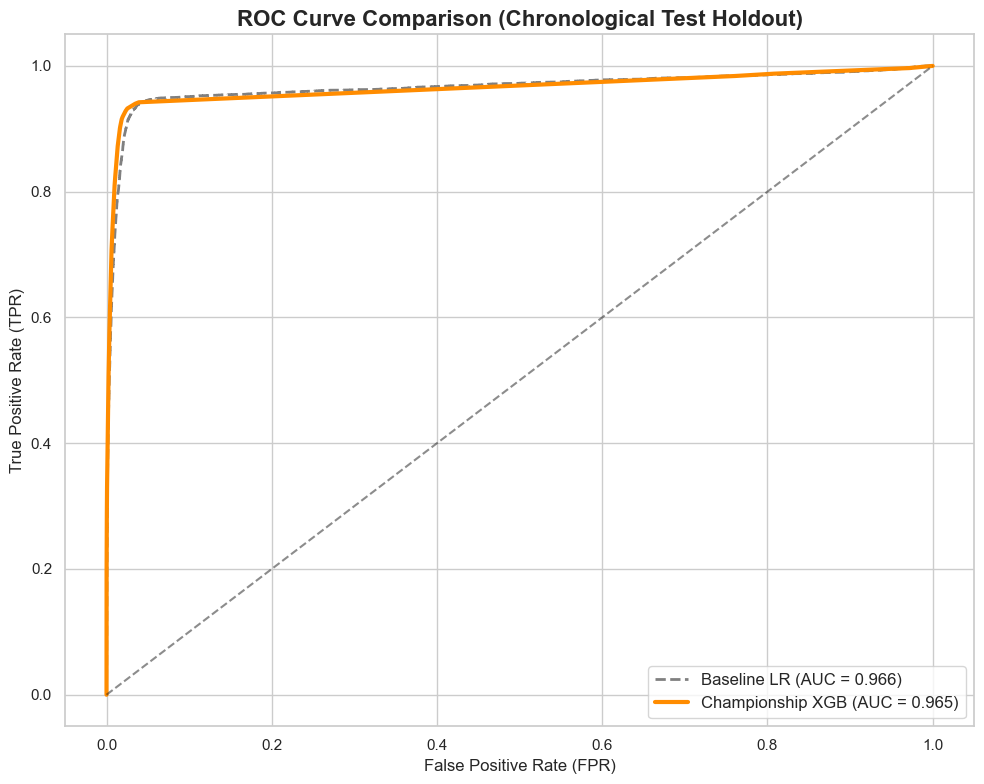

In [7]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(10, 8))
plt.plot(lr_fpr, lr_tpr, label=f"Baseline LR (AUC = {lr_auc:.3f})", linestyle='--', color='gray', linewidth=2)
plt.plot(xgb_fpr, xgb_tpr, label=f"Championship XGB (AUC = {xgb_auc:.3f})", color='darkorange', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title("ROC Curve Comparison (Chronological Test Holdout)", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=300)
plt.show()

### Plot Calibration Curve

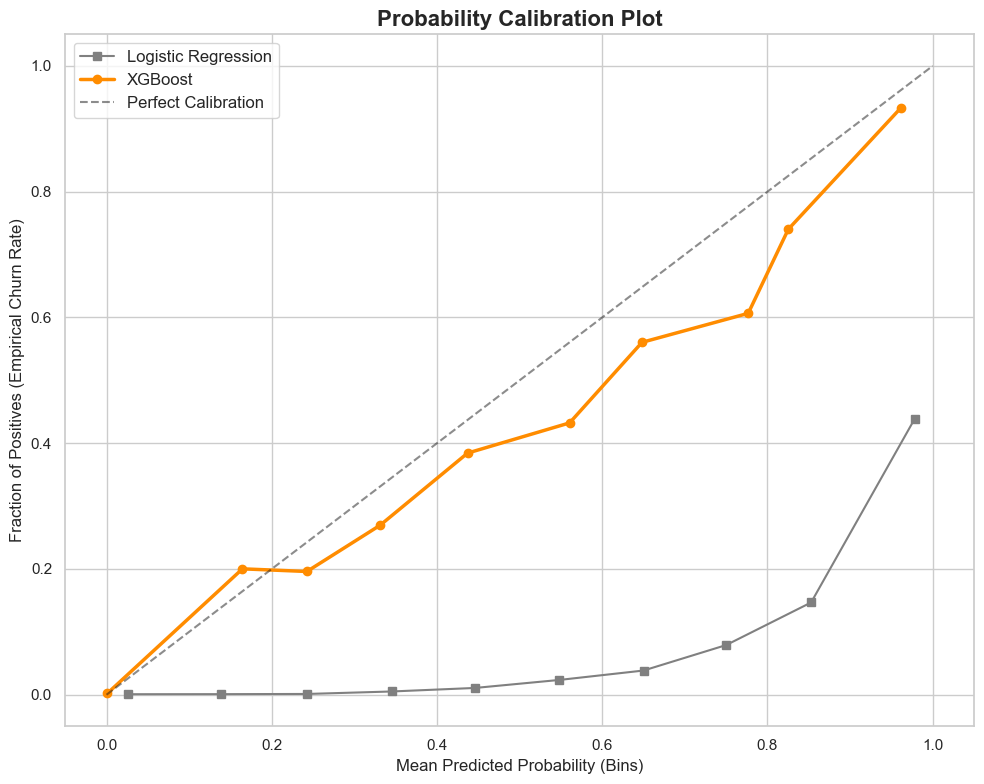

In [8]:
prob_true_lr, prob_pred_lr = calibration_curve(y_test, lr_probs, n_bins=10)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)

plt.figure(figsize=(10, 8))
plt.plot(prob_pred_lr, prob_true_lr, "s-", label=f"Logistic Regression", color='gray')
plt.plot(prob_pred_xgb, prob_true_xgb, "o-", label=f"XGBoost", color='darkorange', linewidth=2.5)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect Calibration")
plt.title("Probability Calibration Plot", fontsize=16, fontweight='bold')
plt.xlabel("Mean Predicted Probability (Bins)", fontsize=12)
plt.ylabel("Fraction of Positives (Empirical Churn Rate)", fontsize=12)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig("calibration_comparison.png", dpi=300)
plt.show()

### Plot Confusion Matrix at Chosen Threshold

Since our baseline churn density is low, we pick a threshold that maximizes F1 or prioritizes precision. Let's look at the metrics at an operational threshold (e.g. 0.35).

Classification Report for XGBoost at Threshold = 0.35:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    564684
           1       0.60      0.75      0.67      8595

    accuracy                           0.99    573279
   macro avg       0.80      0.87      0.83    573279
weighted avg       0.99      0.99      0.99    573279



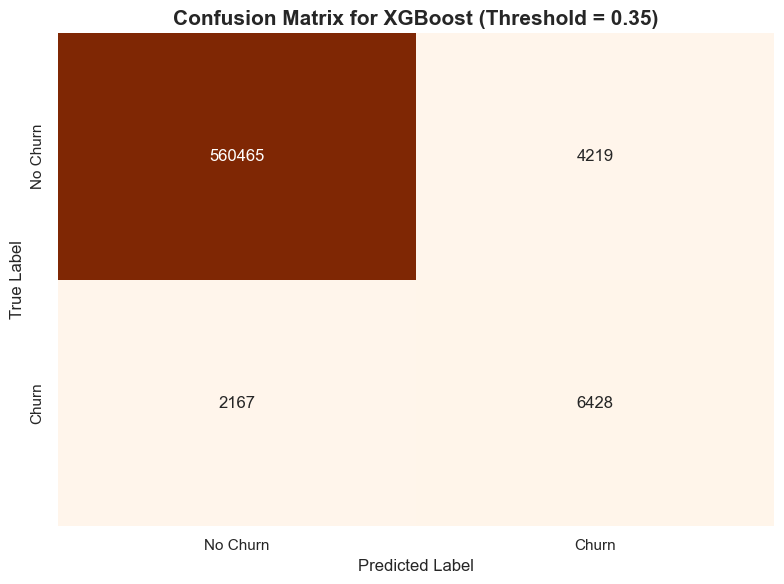

In [9]:
threshold = 0.35
xgb_preds_threshold = (xgb_probs >= threshold).astype(int)

print(f"Classification Report for XGBoost at Threshold = {threshold}:")
print(classification_report(y_test, xgb_preds_threshold))

cm = confusion_matrix(y_test, xgb_preds_threshold)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title(f"Confusion Matrix for XGBoost (Threshold = {threshold})", fontsize=15, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

## 6. Feature Importance Chart

/var/folders/pt/wmxj_98525gfgmgpb2lz5_xw0000gn/T/ipykernel_84274/3509348263.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Oranges_r")


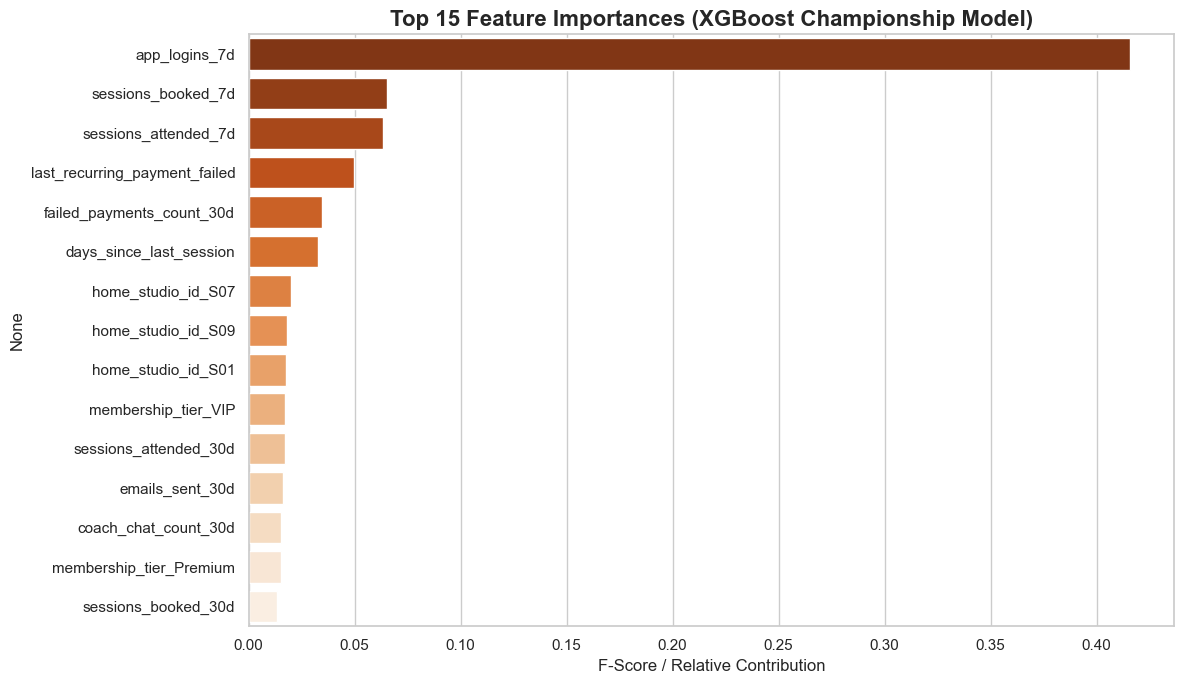

In [10]:
# Get feature names from ColumnTransformer
onehot_features = list(xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols))
all_features = numeric_cols + onehot_features + boolean_cols

# Extract importances
importances = xgb_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Oranges_r")
plt.title("Top 15 Feature Importances (XGBoost Championship Model)", fontsize=16, fontweight='bold')
plt.xlabel("F-Score / Relative Contribution", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=300)
plt.show()

## 7. Demographic Slice / Fairness Check

We evaluate how the model scores differ across genders and home studio locations, confirming the model doesn't exhibit proxy discrimination.

In [11]:
# Build evaluation dataframe
fairness_df = test_df.copy()
fairness_df['predicted_prob'] = xgb_probs
fairness_df['predicted_churn'] = xgb_preds_threshold

# 1. Slice Analysis by Gender
print("=== SLICE ANALYSIS: GENDER ===")
gender_slice = fairness_df.groupby('gender').agg(
    records=('is_churned_14d', 'count'),
    observed_churn_rate=('is_churned_14d', 'mean'),
    avg_predicted_prob=('predicted_prob', 'mean'),
    predicted_churn_rate=('predicted_churn', 'mean')
).reset_index()
print(gender_slice.to_string(index=False))

# 2. Slice Analysis by Home Studio (checking proxy variation)
print("\n=== SLICE ANALYSIS: HOME STUDIO ===")
studio_slice = fairness_df.groupby('home_studio_id').agg(
    records=('is_churned_14d', 'count'),
    observed_churn_rate=('is_churned_14d', 'mean'),
    avg_predicted_prob=('predicted_prob', 'mean'),
    predicted_churn_rate=('predicted_churn', 'mean')
).reset_index()
print(studio_slice.to_string(index=False))

=== SLICE ANALYSIS: GENDER ===
gender  records  observed_churn_rate  avg_predicted_prob  predicted_churn_rate
     F   371721             0.015044            0.015898              0.019224
     M   173111             0.014933            0.014853              0.017116
 Other    28447             0.014694            0.016106              0.018912

=== SLICE ANALYSIS: HOME STUDIO ===
home_studio_id  records  observed_churn_rate  avg_predicted_prob  predicted_churn_rate
           S01    55031             0.013901            0.014884              0.018081
           S02    56126             0.017318            0.016571              0.020044
           S03    56703             0.015167            0.015529              0.018324
           S04    67512             0.013449            0.013931              0.016945
           S05    57023             0.015257            0.013214              0.015678
           S06    57452             0.015474            0.017103              0.020765
       

## 8. Serialize Preprocessing & Modeling Pipeline

In [12]:
# Serialize the CALIBRATED pipeline so downstream scoring gets honest probabilities.
# (Feature importances above were read from the underlying xgb_pipeline, which the
#  FrozenEstimator wraps without modifying.)
model_path = os.path.join(MODELS_DIR, "churn_model_pipeline.joblib")
joblib.dump(calibrated_xgb, model_path)
print(f"Successfully saved serialised, calibrated XGBoost pipeline to: {model_path}")

Successfully saved serialised, calibrated XGBoost pipeline to: ./models/churn_model_pipeline.joblib
